# 02 · Content — category flow

**One notebook, one input.** This merges the four FOR artefacts of analysis 02 —
`02_content_2_for_analysis.ipynb`, `02_content_3_for_growing.ipynb`,
`02_content_4_top10_broad_research_areas.py` and
`02_content_5_top10_fastest_growing_research_areas.py` — and runs every one of them off
`data/showcase/showcase_plus/showcase_plus_all_endpoints_wide.parquet` as the sole source.

What changed relative to those four files:

| | before | now |
|---|---|---|
| input | `df_dimensions.xlsx` (retired) / hardcoded literals | the all-endpoints parquet, via `shared_showcase.load_showcase` |
| FOR parsing | a local `ast.literal_eval` helper that silently emptied the table against JSON | `shared_for` (`for_long`, `parse_listcol`, `split_for_name`) |
| §5's counts | literals with no provenance | derived from the corpus |
| figures | inline `#1b82b1`, `output/figures/` | the project palette, `savefig`, `output/figures/data_analysis/02_content/` |

**Sections.** §3–§5 are the preserved analyses. §6 and §7 are new: a per-year-normalised
flow of category shares over 2014–2025, once on FOR L4 fields and once on RCDC tags. §8
states where this notebook does and does not overlap
`03_academic_impact_01_for_analysis.ipynb`.

In [1]:
import sys
from pathlib import Path

ROOT = next(p for p in [Path.cwd(), *Path.cwd().parents] if (p / "src" / "utils").is_dir())
sys.path.insert(0, str(ROOT / "src"))
from utils import shared_paths as P
_ = P.bootstrap()

In [2]:
import matplotlib.patheffects as pe
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display

from utils import shared_for as F
from utils import shared_name_gender as G
from utils import shared_rcdc as R
from utils.shared_showcase import item_names, load_showcase
from utils.shared_style import extended_palette, load_style, savefig, year_ticks

STYLE = load_style("02_content")
REG = P.ArtifactRegistry(P.TABLE_CONTENT)
P.ensure_dirs()

print("figures ->", STYLE["savedir"], f"(save={STYLE['save']})")
print("tables  ->", P.raw_path(P.TABLE_CONTENT))
print("derived ->", P.raw_path(P.CONTENT))

figures -> output/figures/data_analysis/02_content (save=True)
tables  -> output/tables/02_content
derived -> data/analysis/content


## 1. Parameters

**What a weight means.** `n_papers` is *whole* counting: a paper counts once in every
category it carries, so a year's total exceeds that year's paper count. `n_frac` is
*fractional*: each paper spreads a total weight of 1 evenly across its categories, so a
year's total equals the number of papers carrying ≥1 category.

**Both normalise to 100% per year.** They differ in what the denominator means, not in
whether the stack closes. The defaults differ between §6 and §7 on purpose:

| vocabulary | categories per paper | default weight | why |
|---|---|---|---|
| FOR L4 | ~1.5 | `n_papers` | whole counting barely inflates; the count reads as "papers in this field" |
| RCDC | ~7.4 | `n_frac` | whole counting inflates ~5× against the paper count, and a paper tagged with 20 conditions would outvote one tagged with two |

`times_cited` and `altmetric` are also accepted: the same whole-counting shape, with the
metric in place of the 1. They answer "what share of attention", not "what share of output".

In [3]:
# ---- weights -------------------------------------------------------------------------
FOR_WEIGHT  = "n_papers"     # §6 — "n_papers" | "n_frac" | "times_cited" | "altmetric"
RCDC_WEIGHT = "n_frac"       # §7 — same options

# ---- the flow window -----------------------------------------------------------------
FLOW_MIN, FLOW_MAX = 2014, 2025
TOP_N_FLOW  = 12             # categories drawn as their own band; the rest pool together
OTHER_LABEL = "All other categories"

# ---- RCDC's mixed vocabulary (see shared_rcdc) ---------------------------------------
RCDC_VIEW   = "all"          # "all" | "disease" | "cross-cutting"

# ---- the preserved analyses ----------------------------------------------------------
TOP_N_TABLE = 10             # §3 and §5's top-N tables
GROWTH_FROM, GROWTH_TO = 2024, 2025   # §4's naive single-year delta
RUN_GENDER  = True           # §3/§4's percent_female (shared cached inference)

# ---- 03's window, for the reconciliation in §8 ---------------------------------------
API_MIN, API_MAX = 2015, 2025

assert FLOW_MIN < FLOW_MAX and TOP_N_FLOW >= 1
assert RCDC_VIEW in {"all", "disease", "cross-cutting"}
FLOW_YEARS = list(range(FLOW_MIN, FLOW_MAX + 1))
print(f"flow window {FLOW_MIN}-{FLOW_MAX} | FOR weight {FOR_WEIGHT} | "
      f"RCDC weight {RCDC_WEIGHT} (view: {RCDC_VIEW}) | top {TOP_N_FLOW} + '{OTHER_LABEL}'")

flow window 2014-2025 | FOR weight n_papers | RCDC weight n_frac (view: all) | top 12 + 'All other categories'


## 2. The corpus — the sole input

Everything below reads this one frame. The nested columns are **JSON**, and the local
`ast.literal_eval` parser the two source notebooks carried rejected `null`, returned `None`,
and hit a `continue` guard that skipped every row — so those notebooks completed
successfully with empty tables. That helper is gone; `load_showcase` and `shared_for` do the
parsing now.

Two derived long tables come out of this section:

- `for_pairs` — one row per (paper, L2 division, L4 field), from `F.for_long`.
- `rcdc_pairs` — one row per (paper, RCDC tag). RCDC is a **flat** vocabulary: no levels, no
  parent, no code hierarchy, so there is nothing to explode.

In [4]:
COLS = ["id", "year", "times_cited", "altmetric", "category_for_2020", "category_rcdc",
        "researchers", "research_org_names"]
NESTED = ["category_for_2020", "category_rcdc", "researchers", "research_org_names"]

df = load_showcase(columns=COLS, parse=NESTED)
df["year"] = pd.to_numeric(df["year"], errors="coerce").astype("Int64")
df["times_cited"] = pd.to_numeric(df["times_cited"], errors="coerce").fillna(0)
df["altmetric"] = pd.to_numeric(df["altmetric"], errors="coerce").fillna(0)

print(f"{P.raw_path(P.SHOWCASE_PLUS)}: {len(df):,} papers, "
      f"{int(df.year.min())}-{int(df.year.max())}")

data/showcase/showcase_plus/showcase_plus_all_endpoints_wide.parquet: 26,109 papers, 2013-2026


In [5]:
# ---- FOR: the L2xL4 long table -------------------------------------------------------
F.add_for_columns(df, fold_parents=True)
display(F.for_coverage(df))

for_pairs = F.for_long(df, carry=("year", "times_cited", "altmetric"))

# The pairing rule 02_content_2/3 used required the 2-digit division to be tagged on the
# paper as well; deriving it from code[:2] does not. Assert rather than assume they agree.
_strict = F.for_long(df, carry=("year",), parent_from_code=False)
_a = set(map(tuple, for_pairs[["id", "l4_code"]].drop_duplicates().itertuples(index=False)))
_b = set(map(tuple, _strict[["id", "l4_code"]].drop_duplicates().itertuples(index=False)))
assert _a == _b, f"{len(_a ^ _b)} (paper, L4) pairs differ between the two parent rules"
print(f"FOR L4: {len(for_pairs):,} (paper, division, field) rows | "
      f"{for_pairs.id.nunique():,} papers | {for_pairs.l4_code.nunique()} fields | "
      f"{len(for_pairs) / for_pairs.id.nunique():.2f} codes/paper")
print(f"  the two parent rules agree exactly on all {len(_a):,} (paper, L4) pairs")
del _strict, _a, _b

,level,papers_with_>=1,%,distinct_labels
0,for_l2,26086,99.9,21
1,for_l4,25402,97.3,119


FOR L4: 37,719 (paper, division, field) rows | 25,402 papers | 119 fields | 1.48 codes/paper
  the two parent rules agree exactly on all 37,719 (paper, L4) pairs


In [6]:
# ---- RCDC: flat, so a plain explode --------------------------------------------------
rcdc_tags = df["category_rcdc"].apply(lambda c: sorted(set(item_names(c))))
rcdc_pairs = (df[["id", "year", "times_cited", "altmetric"]]
              .assign(rcdc=rcdc_tags)
              .explode("rcdc")
              .dropna(subset=["rcdc"])
              .reset_index(drop=True))

_tagged = rcdc_pairs.id.nunique()
print(f"RCDC: {len(rcdc_pairs):,} (paper, tag) rows | {_tagged:,} papers with >=1 tag "
      f"({100 * _tagged / len(df):.1f}%) | {rcdc_pairs.rcdc.nunique()} distinct tags | "
      f"{len(rcdc_pairs) / _tagged:.1f} tags per tagged paper")

_disease = sorted(t for t in rcdc_pairs.rcdc.unique() if R.is_disease(t))
print(f"  of those tags, {len(_disease)} name a condition and "
      f"{rcdc_pairs.rcdc.nunique() - len(_disease)} are cross-cutting (shared_rcdc)")

RCDC: 190,511 (paper, tag) rows | 25,743 papers with >=1 tag (98.6%) | 271 distinct tags | 7.4 tags per tagged paper
  of those tags, 179 name a condition and 92 are cross-cutting (shared_rcdc)


## 3. Top L4 fields — the preserved `02_content_2` summary

The twelve columns of the original, unchanged in definition. Two things to hold on to:

- **`papers` counts paper-field pairs, not papers.** A paper tagged with three L4 fields
  appears under all three.
- **`percent_female` uses the shared offline name-inference utility**: Unicode-safe
  consensus across `gender_guesser`, `gender_detector`, `nomquamgender`,
  `names-dataset`, and `gename`, followed by unanimous linkage across records carrying
  the same Dimensions researcher ID. No online API or remote name cache is used.
  The percentage is over *classified and unclassified alike* — `unknown` sits in the
  denominator, so it is a floor, not an estimate.

In [7]:
print("Name categories: five-library offline ensemble + identity consensus")

Name categories: five-library offline ensemble + identity consensus


In [8]:
# Inferred once per paper, with identity consensus across the nested researcher records,
# then joined onto the field-pair table so multi-field papers do not repeat inference.
people = pd.DataFrame({
    "id": df["id"],
    "orgs": df["research_org_names"].apply(item_names),
}).join(
    G.researcher_list_features(
        df["researchers"], infer_name_categories=RUN_GENDER
    )
)

exploded = for_pairs.merge(people, on="id", how="left", validate="many_to_one")
exploded = exploded.rename(columns={"l2_label": "L2_name", "l4_label": "L4_name"})
gender_summary = G.summarize_name_categories(people["name_gender_categories"])
print(f"{len(exploded):,} rows | {gender_summary.total:,} author slots evaluated | "
      f"{gender_summary.classified:,} classified "
      f"({gender_summary.coverage_percent:.1f}%)")

37,719 rows | 265,536 author slots evaluated | 210,446 classified (79.3%)


In [9]:
def h_index(citations) -> int:
    h = 0
    for i, c in enumerate(sorted(citations, reverse=True), start=1):
        if c >= i:
            h = i
        else:
            break
    return h


def field_summary(frame, fields, field_col="L4_name") -> pd.DataFrame:
    # The twelve-column per-field summary of 02_content_2 / 02_content_3.
    results = []
    for name in fields:
        sub = frame[frame[field_col] == name]
        citations = sub["times_cited"].astype(int)
        researcher_list = [n for lst in sub["researcher_names"] for n in lst]
        org_list = [o for lst in sub["orgs"] for o in lst]
        results.append([
            name,
            sub["L2_name"].mode().iloc[0] if not sub["L2_name"].mode().empty else None,
            len(sub),
            citations.sum(),
            citations.mean(),
            sub["altmetric"].sum(),
            h_index(citations),
            pd.Series(researcher_list).mode().iloc[0] if researcher_list else None,
            len(set(researcher_list)),
            pd.Series(org_list).mode().iloc[0] if org_list else None,
            len(set(org_list)),
            G.female_name_percentage(
                sub["name_gender_categories"], denominator="all", empty=0.0
            ),
        ])
    return pd.DataFrame(results, columns=[
        "L4_name", "L2_name", "papers", "total_citations", "mean_citations",
        "total_altmetric", "h_index", "modal_researcher", "unique_researchers",
        "modal_org", "unique_orgs", "percent_female"])


top_L4 = exploded["L4_name"].value_counts().head(TOP_N_TABLE).index.tolist()
res_df = field_summary(exploded, top_L4).sort_values("papers", ascending=False)
REG.save_table(res_df, "for_l4_top_fields_summary.csv")
display(res_df)

saved output/tables/02_content/for_l4_top_fields_summary.csv


,L4_name,L2_name,papers,total_citations,mean_citations,total_altmetric,h_index,modal_researcher,unique_researchers,modal_org,unique_orgs,percent_female
0,Epidemiology,Health Sciences,6930,181499,26.190332,219135.0,177,George Davey Smith,26837,Harvard University,4934,31.333295
1,Clinical Sciences,Biomedical and Clinical Sciences,6080,114160,18.776316,274179.0,142,Steffen Erhard Petersen,26355,University of Oxford,4877,29.931532
2,Genetics,Biological Sciences,5777,241304,41.769777,212843.0,222,Kari Stefansson,28263,Harvard University,5569,33.890588
3,Biological Psychology,Psychology,2405,56677,23.566320,124825.0,104,Andrew Mark Mcintosh,9923,King's College London,2378,33.388089
4,Cardiovascular Medicine and Haematology,Biomedical and Clinical Sciences,2148,48579,22.615922,98447.0,103,Steffen Erhard Petersen,10749,Harvard University,2406,27.994482
5,Public Health,Health Sciences,2138,66527,31.116464,176915.0,115,Jill P Pell,8359,University of Oxford,1961,31.987001
6,Oncology and Carcinogenesis,Biomedical and Clinical Sciences,1522,24846,16.324573,44935.0,69,Marc James Gunter,8020,Harvard University,2019,35.321840
7,Health Services and Systems,Health Sciences,1336,31870,23.854790,85185.0,77,Jill P Pell,7135,University of Oxford,1735,33.766863
8,Nutrition and Dietetics,Biomedical and Clinical Sciences,1261,23054,18.282316,79729.0,76,Aurora Perez-Cornago,5893,Harvard University,1637,32.312992
9,Statistics,Mathematical Sciences,1235,24583,19.905263,15410.0,66,George Davey Smith,4930,University of Bristol,1197,26.689468


## 4. Fastest-growing L4 fields — the preserved `02_content_3` measure

> **Superseded for growth claims.** This is a single-year percentage delta
> (2024 → 2025) on the UK Biobank corpus alone. `03_academic_impact_01_for_analysis.ipynb`
> Chart 11 answers the same question properly: CAGR over 2021–25 against 2017–21, with the
> **whole database's** rate on the same axis as a benchmark and an acceleration term in
> percentage points per year. Where the two disagree, 03 is right.
>
> Three specific weaknesses of the measure below, in the order they bite:
> 1. **No base floor.** A field going 1 → 3 papers scores +200% and outranks a field going
>    400 → 500. 03 applies `GROW_MIN_BASE=5` / `GROW_MIN_LAST=20`.
> 2. **No benchmark.** A field growing 40% in a year that the whole literature grew 40% has
>    not grown *relative to anything*.
> 3. **One interval, so no separation of level from trend.** A single pair of years cannot
>    distinguish sustained growth from a one-year spike.
>
> It is kept because it is what the original notebook computed and the figures drawn from it
> are in circulation, not because it is the better answer.

In [10]:
all_L4 = exploded["L4_name"].unique().tolist()
res_all = field_summary(exploded, all_L4)

counts = (exploded.groupby(["L4_name", "year"]).size().rename("papers").reset_index())
pivot = (counts.pivot(index="L4_name", columns="year", values="papers")
         .fillna(0).astype(int))
missing = [y for y in (GROWTH_FROM, GROWTH_TO) if y not in pivot.columns]
if missing:
    raise KeyError(f"no rows for year(s) {missing} — cannot compute the delta")
pivot = pivot.rename(columns={GROWTH_FROM: "n_from", GROWTH_TO: "n_to"})

valid = pivot[pivot["n_from"] > 0].copy()
valid["growth_pct"] = (valid["n_to"] - valid["n_from"]) / valid["n_from"] * 100
top_growth = valid.sort_values("growth_pct", ascending=False).head(TOP_N_TABLE)

final_table = (res_all
               .merge(top_growth[["n_from", "n_to", "growth_pct"]],
                      left_on="L4_name", right_index=True, how="inner")
               .rename(columns={
                   "L4_name": "Level Four Field of Research",
                   "L2_name": "Level Two Field of Research",
                   "papers": "Total Papers",
                   "total_citations": "Total Citations",
                   "h_index": "H-Index",
                   "total_altmetric": "Total Altmetric",
                   "modal_researcher": "Modal Researcher",
                   "unique_researchers": "Unique Researchers",
                   "percent_female": "Percent Female",
                   "modal_org": "Modal Organisation",
                   "unique_orgs": "Unique Organisations",
                   "n_from": f"n {GROWTH_FROM}",
                   "n_to": f"n {GROWTH_TO}",
                   "growth_pct": "Growth %"})
               [["Level Four Field of Research", "Total Papers",
                 "Level Two Field of Research", "Total Citations", "H-Index",
                 "Total Altmetric", "Modal Researcher", "Unique Researchers",
                 "Percent Female", "Modal Organisation", "Unique Organisations",
                 f"n {GROWTH_FROM}", f"n {GROWTH_TO}", "Growth %"]]
               .sort_values("Growth %", ascending=False))

REG.save_table(res_all.sort_values("papers", ascending=False), "for_l4_all_fields_summary.csv")
REG.save_table(final_table, "for_l4_fastest_growing_naive.csv")
display(final_table)

saved output/tables/02_content/for_l4_all_fields_summary.csv
saved output/tables/02_content/for_l4_fastest_growing_naive.csv


,Level Four Field of Research,Total Papers,Level Two Field of Research,Total Citations,H-Index,Total Altmetric,Modal Researcher,Unique Researchers,Percent Female,Modal Organisation,Unique Organisations,n 2024,n 2025,Growth %
102,Atmospheric Sciences,8,Earth Sciences,13,2,13.0,Binbin Su,58,22.413793,Sun Yat-sen University,19,1,7,600.0
37,Human Geography,32,Human Society,639,12,2261.0,Kate E Mason,130,30.303030,London School of Hygiene & Tropical Medicine,70,1,6,500.0
73,Applied Economics,12,Economics,69,4,112.0,Stephanie Von Hinke,38,30.232558,China Agricultural University,23,1,4,300.0
100,Environmental Engineering,5,Engineering,19,2,8.0,Bing-Ying Deng,41,21.951220,Sun Yat-sen University,10,1,4,300.0
74,Econometrics,20,Economics,57,4,32.0,Baoluo Sun,44,21.818182,Yale University,22,2,7,250.0
95,Chemical Engineering,13,Engineering,12,2,32.0,An Pan,68,20.588235,Addenbrooke's Hospital,35,2,7,250.0
3,Applied and Developmental Psychology,70,Psychology,1107,16,2158.0,Sarah D Bauermeister,430,30.947776,King's College London,194,7,21,200.0
51,Artificial Intelligence,17,Information and Computing Sciences,95,4,16.0,Andrew Peter King,43,24.137931,King's College London,27,3,9,200.0
52,Information Systems,9,Information and Computing Sciences,95,4,26.0,Abdullah Mesut Erzurumluoglu,61,26.229508,Barts Health NHS Trust,25,1,3,200.0
75,Electrical Engineering,6,Engineering,61,4,1.0,Alauddin Bhuiyan,24,16.666667,Colorado School of Public Health,12,1,3,200.0


## 5. The volume charts

`02_content_4` and `02_content_5` each carried a `build_data()` returning a literal frame —
no data load, no recorded snapshot, window or level. Both are redrawn here from the corpus.

**The old chart was wrong about its own level.** "10 Most Common Areas of *Broad* Research"
listed Clinical Sciences, Epidemiology, Genetics, Public Health — every one of which is a
4-digit **L4 field**, not a 2-digit L2 division. The title said "broad"; the data was
narrow. Titles below state their level.

The literals are printed once beside the recreated counts so the drift is on the record, and
then they are gone.

**Two RCDC rankings are added alongside them** (§5c, §5d), because "what does UK Biobank
publish on" has two different answers in that vocabulary and neither is wrong — see the note
above §5c.

In [11]:
LITERAL_COMMON = pd.DataFrame({
    "area": ["Clinical Sciences", "Epidemiology", "Genetics", "Public Health",
             "Cardiovascular Medicine / Haematology", "Biological Psychology",
             "Nutrition and Dietetics", "Oncology and Carcinogenesis",
             "Health Services and Systems", "Neurosciences"],
    "count": [2635, 2425, 2145, 1067, 967, 817, 678, 648, 581, 459]})
LITERAL_GROWTH = pd.DataFrame({
    "area": ["Bioinformatics and Computational Biology", "Human Geography", "Paediatrics",
             "Medical Biotechnology", "Econometrics", "Analytical Chemistry",
             "Distributed Computing/Systems", "Electrical Engineering",
             "Information Systems", "Atmospheric Sciences"],
    "count": [111, 18, 18, 13, 6, 5, 5, 5, 4, 4]})


def side_by_side(recreated, literal, value_name):
    # Rank-for-rank comparison; not joined, because the label spellings never matched.
    n = max(len(recreated), len(literal))
    return pd.DataFrame({
        "rank": range(1, n + 1),
        "recreated (this corpus)": list(recreated.index[:n]) + [""] * (n - len(recreated)),
        value_name: list(recreated.values[:n]) + [np.nan] * (n - len(recreated)),
        "2026 literal": list(literal["area"][:n]) + [""] * (n - len(literal)),
        "literal count": list(literal["count"][:n]) + [np.nan] * (n - len(literal)),
    }).set_index("rank")


def barh_chart(series, title, xlabel, name, note=None):
    # Bar length already encodes magnitude, so use one semantic colour throughout.
    bar_color = STYLE["colors"][0]
    fig, ax = plt.subplots(figsize=STYLE["figsize_wide"])
    vals = series.iloc[::-1]
    bars = ax.barh(vals.index, vals.values, color=bar_color,
                   edgecolor="white", linewidth=0.8, height=0.72)
    ax.set_title(title, fontweight="bold", pad=14)
    ax.set_xlabel(xlabel)
    ax.grid(axis="x", alpha=0.25)
    ax.set_axisbelow(True)
    ax.tick_params(axis="y", length=0)
    xmax = float(vals.max()) * 1.10
    ax.set_xlim(0, xmax)
    for bar, value in zip(bars, vals.values):
        ax.text(bar.get_width() + xmax * 0.008, bar.get_y() + bar.get_height() / 2,
                f"{value:,.0f}" if float(value) == int(value) else f"{value:,.1f}",
                va="center", ha="left", fontsize=STYLE["annot_fs"], fontweight="bold")
    if note:
        ax.text(0, -0.13, note, transform=ax.transAxes, fontsize=STYLE["annot_fs"] - 1,
                color="#555555", va="top")
    fig.tight_layout()
    REG.record_figures(savefig(fig, name))
    plt.show()

,recreated (this corpus),recreated count,2026 literal,literal count
rank,,,,
1,Epidemiology,6930,Clinical Sciences,2635
2,Clinical Sciences,6080,Epidemiology,2425
3,Genetics,5777,Genetics,2145
4,Biological Psychology,2405,Public Health,1067
5,Cardiovascular Medicine and Haematology,2148,Cardiovascular Medicine / Haematology,967
6,Public Health,2138,Biological Psychology,817
7,Oncology and Carcinogenesis,1522,Nutrition and Dietetics,678
8,Health Services and Systems,1336,Oncology and Carcinogenesis,648
9,Nutrition and Dietetics,1261,Health Services and Systems,581


saved output/figures/data_analysis/02_content/05a_for_l4_most_common.pdf
saved output/figures/data_analysis/02_content/05a_for_l4_most_common.svg


saved output/figures/data_analysis/02_content/05a_for_l4_most_common.png


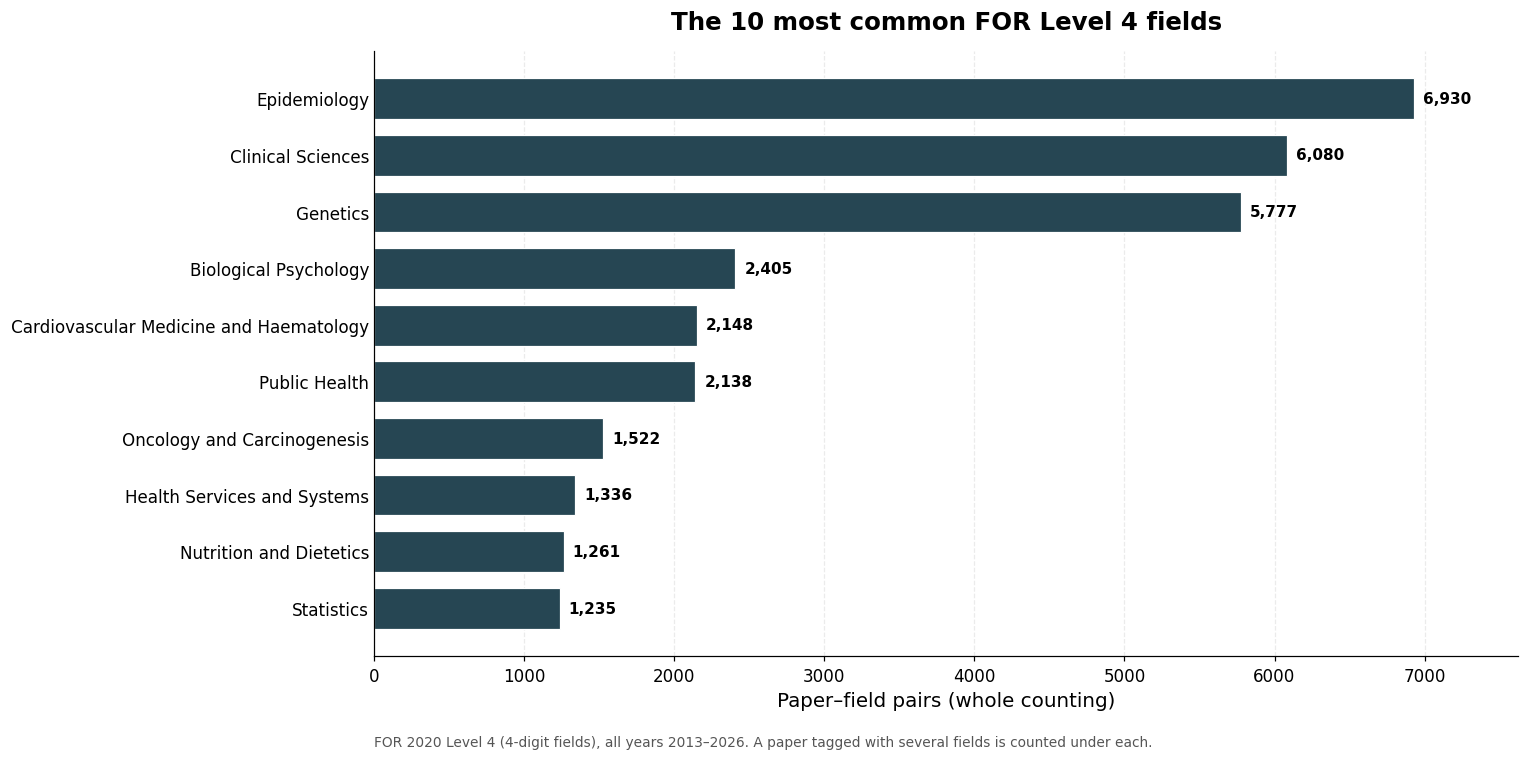

In [12]:
# ---- 5a. most common L4 fields (was 02_content_4) -------------------------------------
common = (exploded["L4_name"].value_counts().head(TOP_N_TABLE))
display(side_by_side(common, LITERAL_COMMON, "recreated count"))

barh_chart(
    common,
    f"The {TOP_N_TABLE} most common FOR Level 4 fields",
    "Paper–field pairs (whole counting)",
    "05a_for_l4_most_common",
    note=(f"FOR 2020 Level 4 (4-digit fields), all years {int(df.year.min())}–"
          f"{int(df.year.max())}. A paper tagged with several fields is counted under each."))

,recreated (this corpus),growth %,2026 literal,literal count
rank,,,,
1,Atmospheric Sciences,600.0,Bioinformatics and Computational Biology,111
2,Human Geography,500.0,Human Geography,18
3,Environmental Engineering,300.0,Paediatrics,18
4,Applied Economics,300.0,Medical Biotechnology,13
5,Econometrics,250.0,Econometrics,6
6,Chemical Engineering,250.0,Analytical Chemistry,5
7,Electrical Engineering,200.0,Distributed Computing/Systems,5
8,Information Systems,200.0,Electrical Engineering,5
9,Applied and Developmental Psychology,200.0,Information Systems,4


saved output/figures/data_analysis/02_content/05b_for_l4_fastest_growing.pdf


saved output/figures/data_analysis/02_content/05b_for_l4_fastest_growing.svg


saved output/figures/data_analysis/02_content/05b_for_l4_fastest_growing.png


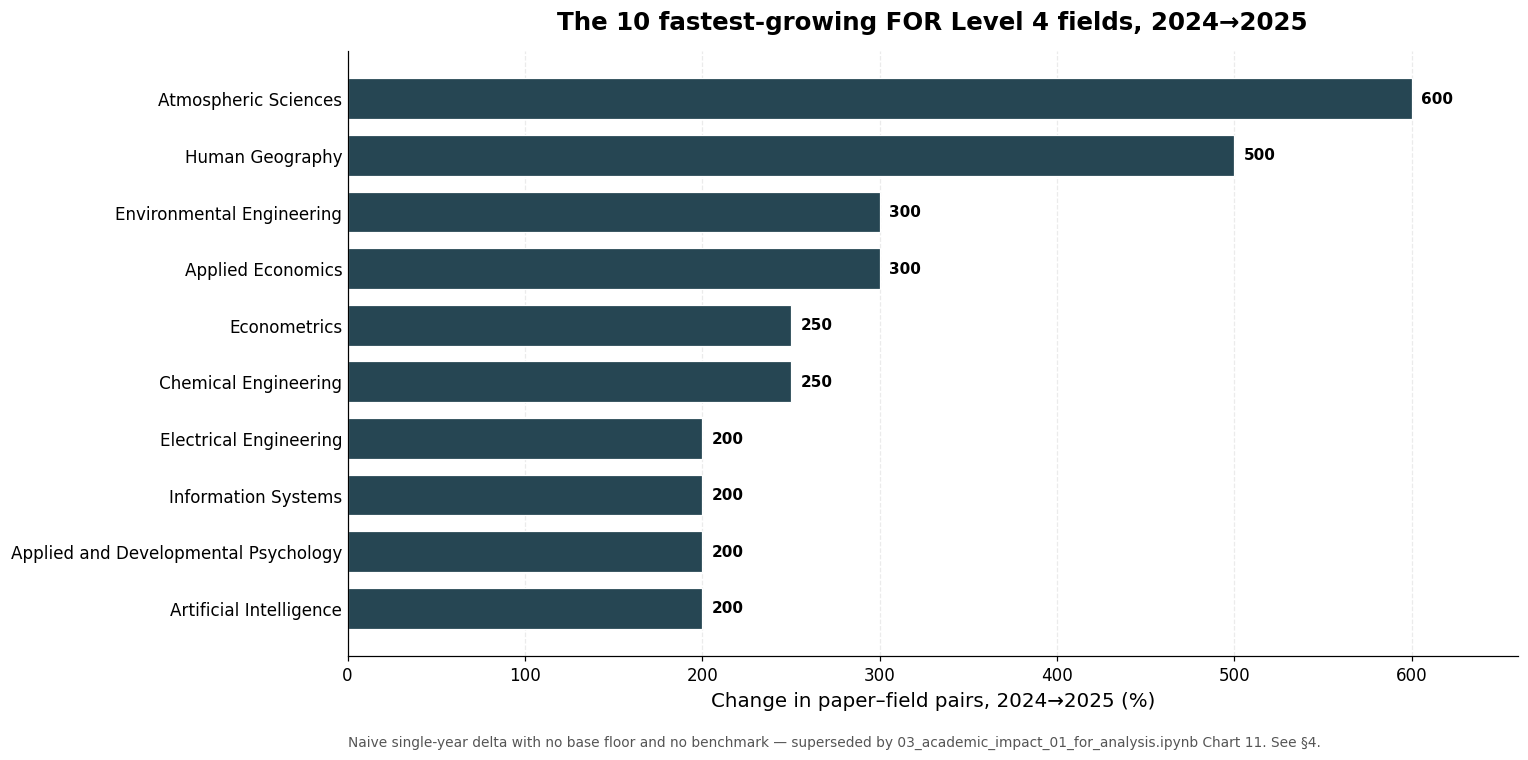

In [13]:
# ---- 5b. fastest-growing L4 fields (was 02_content_5) ---------------------------------
growth = (top_growth["growth_pct"].sort_values(ascending=False).head(TOP_N_TABLE))
display(side_by_side(growth.round(1), LITERAL_GROWTH, "growth %"))

barh_chart(
    growth,
    f"The {TOP_N_TABLE} fastest-growing FOR Level 4 fields, {GROWTH_FROM}→{GROWTH_TO}",
    f"Change in paper–field pairs, {GROWTH_FROM}→{GROWTH_TO} (%)",
    "05b_for_l4_fastest_growing",
    note=("Naive single-year delta with no base floor and no benchmark — superseded by "
          "03_academic_impact_01_for_analysis.ipynb Chart 11. See §4."))

### The RCDC rankings, and why there are two

RCDC counts papers, not pairs: `rcdc_pairs` holds one row per (paper, tag), so a tag's count
is the number of papers carrying it. No whole-vs-fractional choice arises — that only matters
once categories have to share a fixed total, which is §7's problem, not this one.

**Two charts, because the flat vocabulary answers two questions at once.** RCDC mixes
conditions with research areas, methods and populations, and the *research area* labels win a
raw ranking outright: Genetics, Prevention, Human Genome, Clinical Research and Aging lead
the corpus, and none of them names a disease. That is a real and useful answer to *what kind
of research is this*. It is not an answer to *what is it about*.

`shared_rcdc.is_disease` separates the two on an explicit stop list — readable and arguable,
not a heuristic. §5c ranks the whole vocabulary; §5d ranks conditions only. **Neither is the
corrected version of the other**; they have different denominators and answer different
questions, and a figure taken from one and captioned as the other is the specific mistake
this pair exists to prevent.

,all tags,papers,disease tags only,papers
rank,,,,
1,Genetics,13555,Brain Disorders,6879
2,Prevention,13425,Cardiovascular,6410
3,Human Genome,9874,Heart Disease,4396
4,Clinical Research,8151,Neurodegenerative,3563
5,Aging,7623,Mental Health,3331
6,Brain Disorders,6879,Cancer,3080
7,Neurosciences,6417,Obesity,2808
8,Cardiovascular,6410,Acquired Cognitive Impairment,2439
9,Women's Health,4864,Diabetes,2432


25,743 papers carry >=1 RCDC tag; 21,524 (83.6%) carry >=1 DISEASE tag
of the top 10 tags overall, 2 name a condition
saved output/tables/02_content/rcdc_tag_counts_all.csv
saved output/tables/02_content/rcdc_tag_counts_disease.csv


saved output/figures/data_analysis/02_content/05c_rcdc_most_common_all.pdf
saved output/figures/data_analysis/02_content/05c_rcdc_most_common_all.svg


saved output/figures/data_analysis/02_content/05c_rcdc_most_common_all.png


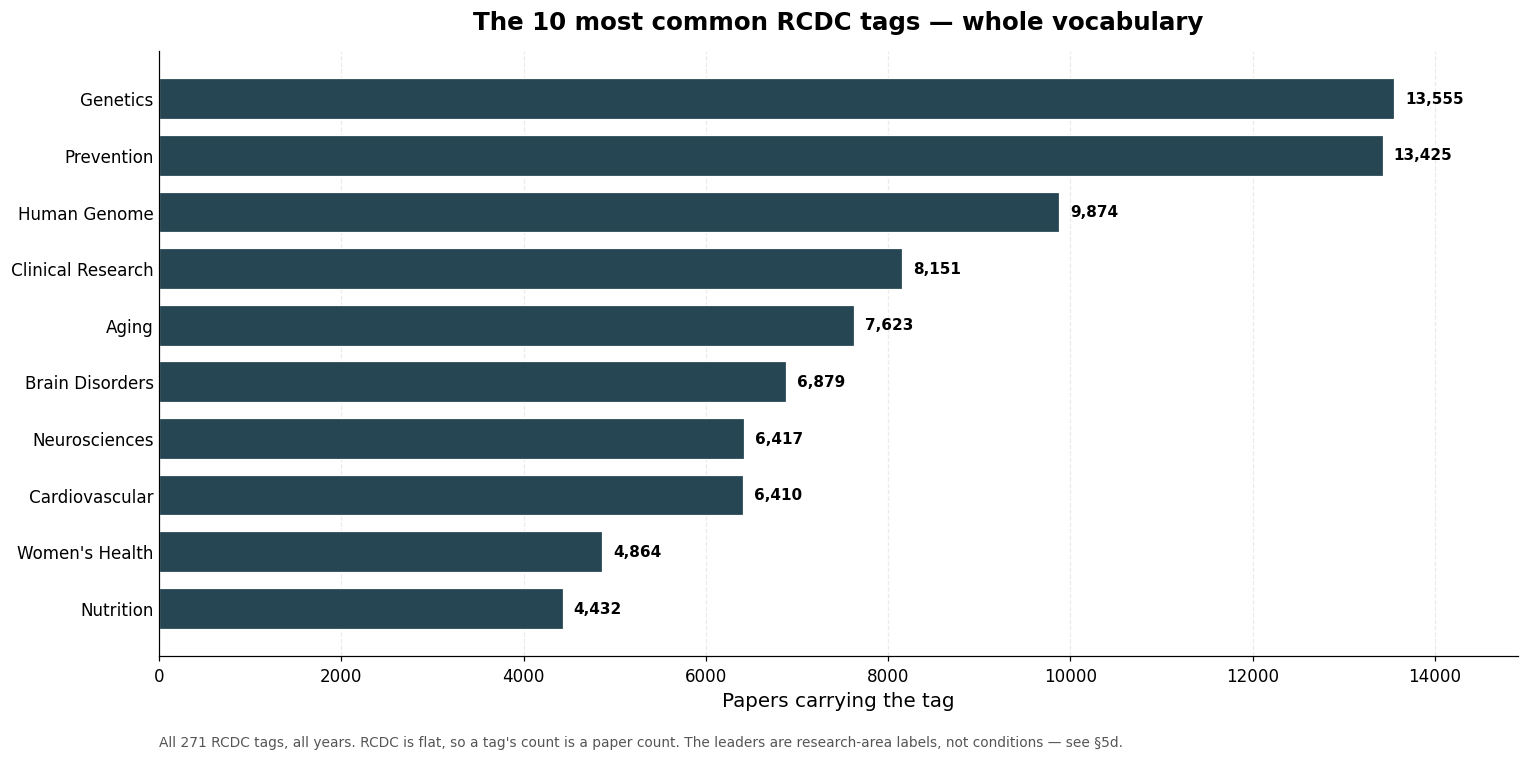

In [14]:
# ---- 5c. most common RCDC tags, whole vocabulary --------------------------------------
rcdc_common_all = rcdc_pairs["rcdc"].value_counts()
rcdc_common_dis = rcdc_pairs.loc[rcdc_pairs["rcdc"].map(R.is_disease), "rcdc"].value_counts()

compare = pd.DataFrame({
    "rank": range(1, TOP_N_TABLE + 1),
    "all tags": rcdc_common_all.head(TOP_N_TABLE).index,
    "papers": rcdc_common_all.head(TOP_N_TABLE).values,
    "disease tags only": rcdc_common_dis.head(TOP_N_TABLE).index,
    "papers ": rcdc_common_dis.head(TOP_N_TABLE).values,
}).set_index("rank")
display(compare)

_n_tagged = rcdc_pairs.id.nunique()
_n_dis = rcdc_pairs.loc[rcdc_pairs["rcdc"].map(R.is_disease), "id"].nunique()
print(f"{_n_tagged:,} papers carry >=1 RCDC tag; {_n_dis:,} ({100 * _n_dis / _n_tagged:.1f}%) "
      f"carry >=1 DISEASE tag")
print(f"of the top {TOP_N_TABLE} tags overall, "
      f"{sum(R.is_disease(t) for t in rcdc_common_all.head(TOP_N_TABLE).index)} name a condition")

REG.save_table(rcdc_common_all.rename("papers").rename_axis("rcdc_tag").reset_index(),
               "rcdc_tag_counts_all.csv")
REG.save_table(rcdc_common_dis.rename("papers").rename_axis("rcdc_tag").reset_index(),
               "rcdc_tag_counts_disease.csv")

barh_chart(
    rcdc_common_all.head(TOP_N_TABLE),
    f"The {TOP_N_TABLE} most common RCDC tags — whole vocabulary",
    "Papers carrying the tag",
    "05c_rcdc_most_common_all",
    note=("All 271 RCDC tags, all years. RCDC is flat, so a tag's count is a paper count. "
          "The leaders are research-area labels, not conditions — see \u00a75d."))

saved output/figures/data_analysis/02_content/05d_rcdc_most_common_disease.pdf


saved output/figures/data_analysis/02_content/05d_rcdc_most_common_disease.svg


saved output/figures/data_analysis/02_content/05d_rcdc_most_common_disease.png


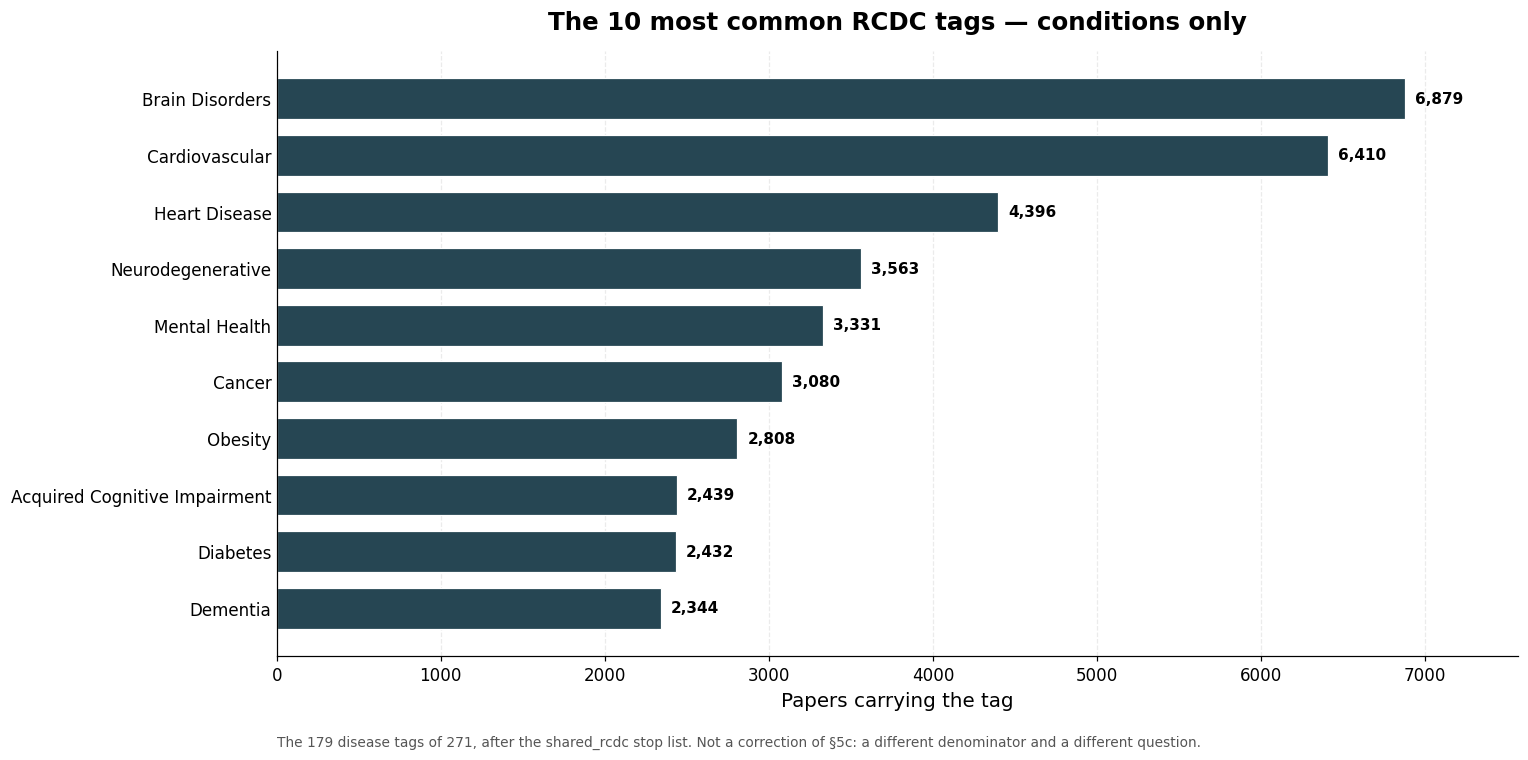

In [15]:
# ---- 5d. most common RCDC tags, conditions only ---------------------------------------
barh_chart(
    rcdc_common_dis.head(TOP_N_TABLE),
    f"The {TOP_N_TABLE} most common RCDC tags — conditions only",
    "Papers carrying the tag",
    "05d_rcdc_most_common_disease",
    note=(f"The {len(rcdc_common_dis)} disease tags of 271, after the shared_rcdc stop list. "
          "Not a correction of \u00a75c: a different denominator and a different question."))

## 6. FOR L4 flow, 2014–2025 — **new**

The question §3–§5 cannot answer: **not** how big a field is, but *what share of UK
Biobank's output it accounts for in a given year, and how that share moves.*

Each year is normalised independently, so every year's shares sum to **100%** and the
figure is about composition rather than volume. A field whose band narrows is not
necessarily shrinking — the corpus grew from 27 papers in 2014 to 5,892 in 2025, so almost
everything grew in absolute terms. A narrowing band means *growing more slowly than the
corpus as a whole*.

Normalisation is over **all** L4 fields present in the window. Only the largest
`TOP_N_FLOW` get their own band; the remainder are pooled so the stack still closes at 100%.

**Reading the two rows under the x axis.** The upper row is the publication year. The lower
row is **the number of papers published that year carrying ≥1 category** — the population
the year's shares were computed over. It is *not* the arithmetic denominator: under whole
counting that is the paper–category **pair** total (2014: 36 pairs from 26 papers), and under
fractional counting it equals the paper count exactly. The row is there for one purpose — to
show how much weight each point of the curve is carrying.

**Labelling.** No legend. A band thick enough to hold its own name is labelled in place; the
rest are called out to the right with a leader line and their final-year share, so every band
is named and nothing has to be matched against a swatch.

> **Thin at the left-hand edge.** The flow rests on the papers that actually carry a
> category: **26 in 2014 and 61 in 2015**, against 5,747 in 2025. A share across 119 fields
> computed on 26 papers moves by roughly four percentage points when one paper changes, so
> read the first two years of every flow figure as indicative only. That population is
> printed under each year's tick, so it stays in front of the reader rather than being
> something to remember.

In [16]:
def category_weights(long, cat_col, weight, year_col="year", id_col="id"):
    # year x category weight matrix. Whole for n_papers/metrics, spread for n_frac.
    pairs = long.drop_duplicates([id_col, cat_col]).copy()
    if weight == "n_papers":
        pairs["w"] = 1.0
    elif weight == "n_frac":
        pairs["w"] = 1.0 / pairs.groupby(id_col)[cat_col].transform("size")
    elif weight in pairs.columns:
        pairs["w"] = pd.to_numeric(pairs[weight], errors="coerce").fillna(0.0)
    else:
        raise KeyError(f"unknown weight {weight!r}; column not in the pair table")
    return pairs.pivot_table(index=year_col, columns=cat_col, values="w",
                             aggfunc="sum", fill_value=0.0)


def flow_shares(long, cat_col, weight, years, **kw):
    # (weight matrix, share matrix, per-year paper count); shares sum to 100 per year.
    w = category_weights(long, cat_col, weight, **kw).reindex(years).fillna(0.0)
    w.index.name = "year"
    totals = w.sum(axis=1)
    if (totals <= 0).any():
        raise ValueError(f"no weight at all in year(s) {list(totals[totals <= 0].index)}")
    share = w.div(totals, axis=0) * 100
    assert np.allclose(share.sum(axis=1), 100), "shares do not sum to 100%"
    n_papers = (long[long.year.isin(years)].drop_duplicates("id")
                .groupby("year").size().reindex(years).fillna(0).astype(int))
    return w, share, n_papers


def top_bands(share, w, top_n, other_label=OTHER_LABEL):
    # Largest top_n categories by total in-window weight, plus a closing remainder.
    order = w.sum(axis=0).sort_values(ascending=False)
    keep = list(order.index[:top_n])
    band = share[keep].copy()
    rest = share.drop(columns=keep)
    if len(rest.columns):
        band[other_label] = rest.sum(axis=1)
    assert np.allclose(band.sum(axis=1), 100), "the drawn bands do not close at 100%"
    return band, keep, order

In [17]:
def _weight_note(weight):
    return {"n_papers": "whole counting (a paper counts once per category)",
            "n_frac": "fractional counting (each paper spreads a weight of 1)"}.get(
                weight, f"summed {weight} (whole counting)")


_STROKE = [pe.withStroke(linewidth=2.2, foreground="#00000055")]
LABEL_MIN_IN = 6.5      # a band thinner than this cannot hold its own name


def _spread(ys, min_gap, lo=0.0, hi=100.0):
    # Push a set of label positions apart until none overlaps, keeping the original
    # order and staying inside [lo, hi]. Returns positions in the order given.
    order = sorted(range(len(ys)), key=lambda k: ys[k])
    placed, prev = {}, lo - min_gap
    for k in order:
        y = max(ys[k], prev + min_gap)
        placed[k], prev = y, y
    over = prev - hi
    if over > 0:                       # ran off the top: shift down, then re-settle
        for k in placed:
            placed[k] -= over
        for k in reversed(order[:-1]):
            nxt = order[order.index(k) + 1]
            placed[k] = min(placed[k], placed[nxt] - min_gap)
    return [placed[k] for k in range(len(ys))]


def plot_share_stream(band, n_papers, title, subtitle, name, other_label=OTHER_LABEL):
    labels = list(band.columns)
    colors = extended_palette(len([c for c in labels if c != other_label]))
    if other_label in labels:
        colors = list(colors) + ["#BBBBBB"]
    years = list(band.index)
    cum = band.cumsum(axis=1)
    mid_i = len(years) // 2

    fig, ax = plt.subplots(figsize=(15, 8.5))
    ax.stackplot(years, band.T.values, labels=labels, colors=colors,
                 edgecolor="white", linewidth=0.6)

    # Every band gets a name. A band thick enough to hold its own is labelled in place;
    # the thin ones are called out to the right with a leader line, so the figure needs
    # no legend and no band goes unnamed.
    thin = []
    for j, lab in enumerate(labels):
        if band.iloc[mid_i, j] >= LABEL_MIN_IN:
            ax.text(years[mid_i], cum.iloc[mid_i, j] - band.iloc[mid_i, j] / 2, lab,
                    ha="center", va="center", fontsize=STYLE["annot_fs"] - 1,
                    fontweight="bold", color="white", path_effects=_STROKE, zorder=5)
        else:
            thin.append(j)

    if thin:
        anchors = [cum.iloc[-1, j] - band.iloc[-1, j] / 2 for j in thin]
        targets = _spread(anchors, min_gap=3.4)
        outside = ax.get_yaxis_transform()
        for j, y_a, y_t in zip(thin, anchors, targets):
            ax.annotate(f"{labels[j]}  {band.iloc[-1, j]:.1f}%",
                        xy=(years[-1], y_a), xycoords="data",
                        xytext=(1.035, y_t), textcoords=outside,
                        ha="left", va="center", fontsize=STYLE["annot_fs"] - 1,
                        color=colors[j], fontweight="bold", annotation_clip=False,
                        arrowprops=dict(arrowstyle="-", color=colors[j], lw=1.0,
                                        shrinkA=0, shrinkB=2,
                                        connectionstyle="arc3,rad=0.0"))
        ax.text(1.035, 1.012, f"{years[-1]} share", transform=ax.transAxes,
                ha="left", va="bottom", fontsize=STYLE["annot_fs"] - 2, color="#777777")

    ax.set_xlim(min(years), max(years))
    ax.set_ylim(0, 100)
    # Every year is labelled, with the papers it rests on underneath: the window's first
    # years are thin enough that the reader needs that n in front of them.
    ax.set_xticks(years)
    ax.set_xticklabels([f"{y}\n{n:,}" for y, n in zip(years, n_papers.values)])
    ax.set_yticks(range(0, 101, 20))
    ax.set_yticklabels([f"{v}%" for v in range(0, 101, 20)])
    ax.set_ylabel("Share of the year's total")
    ax.set_xlabel("Publication year, and the papers carrying \u22651 category that year",
                  labelpad=8)
    ax.set_title(title, fontweight="bold", pad=34, x=0.42)
    ax.text(0.42, 1.025, subtitle, transform=ax.transAxes, ha="center", va="bottom",
            fontsize=STYLE["annot_fs"], color="#555555")

    fig.subplots_adjust(left=0.075, right=0.715, top=0.865, bottom=0.135)
    REG.record_figures(savefig(fig, name))
    plt.show()


def plot_rank_flow(share, keep, title, subtitle, name):
    ranks = share[keep].rank(axis=1, ascending=False, method="first")
    years = list(share.index)
    colors = dict(zip(keep, extended_palette(len(keep))))

    fig, ax = plt.subplots(figsize=(16, 8.5))
    # End labels are placed in AXES fraction on x and data on y, so they sit outside the
    # plotting area whatever the window is and can never land on the rank ticks.
    outside = ax.get_yaxis_transform()
    for cat in keep:
        y = ranks[cat].values
        lw = 1.2 + 4.0 * (share[cat].mean() / max(share[keep].mean().max(), 1e-9))
        ax.plot(years, y, color=colors[cat], linewidth=lw, marker="o",
                markersize=STYLE["marker_size"], markeredgecolor="white", markeredgewidth=0.7,
                solid_capstyle="round", zorder=2)
        # The row IS the rank, so carrying it in the end labels keeps the left margin
        # free of a tick column the names would collide with.
        ax.text(-0.012, y[0], f"#{int(y[0])}  {cat}", transform=outside, ha="right",
                va="center", fontsize=STYLE["annot_fs"] - 1, color=colors[cat],
                fontweight="bold", clip_on=False)
        ax.text(1.012, y[-1], f"{cat}  #{int(y[-1])}", transform=outside, ha="left",
                va="center", fontsize=STYLE["annot_fs"] - 1, color=colors[cat],
                fontweight="bold", clip_on=False)

    ax.set_ylim(len(keep) + 0.6, 0.4)
    ax.set_yticks(range(1, len(keep) + 1))
    ax.set_yticklabels([])
    ax.tick_params(axis="y", length=0)
    ax.set_xlim(years[0] - 0.4, years[-1] + 0.4)
    ax.set_xticks(years)
    ax.set_xlabel("Publication year")
    ax.grid(axis="y", alpha=0.25)
    ax.set_axisbelow(True)
    ax.spines["left"].set_visible(False)
    ax.set_title(title, fontweight="bold", pad=30)
    ax.text(0.5, 1.025, subtitle, transform=ax.transAxes, ha="center", va="bottom",
            fontsize=STYLE["annot_fs"], color="#555555")
    fig.subplots_adjust(left=0.265, right=0.735, top=0.86, bottom=0.09)
    REG.record_figures(savefig(fig, name))
    plt.show()


def start_end_table(share, keep, years):
    y0, y1 = years[0], years[-1]
    ranks = share.rank(axis=1, ascending=False, method="first")
    out = pd.DataFrame({
        f"share_{y0}_%": share.loc[y0, keep].round(2),
        f"share_{y1}_%": share.loc[y1, keep].round(2),
        f"rank_{y0}": ranks.loc[y0, keep].astype(int),
        f"rank_{y1}": ranks.loc[y1, keep].astype(int),
    })
    out["delta_pp"] = (out[f"share_{y1}_%"] - out[f"share_{y0}_%"]).round(2)
    out["rank_change"] = out[f"rank_{y0}"] - out[f"rank_{y1}"]   # +ve = moved up
    out = out.sort_values("delta_pp", ascending=False)
    out.index.name = "category"
    return out

In [18]:
for_w, for_share, for_n = flow_shares(
    for_pairs, "l4_label", FOR_WEIGHT, FLOW_YEARS)
for_band, for_keep, for_order = top_bands(for_share, for_w, TOP_N_FLOW)

_cov = for_band.drop(columns=[OTHER_LABEL], errors="ignore").sum(axis=1)
print(f"{for_share.shape[1]} L4 fields in {FLOW_MIN}-{FLOW_MAX}; the top {TOP_N_FLOW} hold "
      f"{_cov.min():.1f}%-{_cov.max():.1f}% of each year (mean {_cov.mean():.1f}%)")
display(for_share[for_keep].round(2))

119 L4 fields in 2014-2025; the top 12 hold 83.5%-90.6% of each year (mean 87.5%)


l4_label,Epidemiology,Clinical Sciences,Genetics,Biological Psychology,Cardiovascular Medicine and Haematology,Public Health,Oncology and Carcinogenesis,Health Services and Systems,Statistics,Nutrition and Dietetics,Neurosciences,Ophthalmology and Optometry
year,,,,,,,,,,,,
2014,8.33,19.44,2.78,0.00,5.56,25.00,2.78,8.33,0.00,8.33,0.00,5.56
2015,16.52,11.30,14.78,5.22,1.74,13.91,3.48,4.35,3.48,1.74,1.74,5.22
2016,16.67,10.42,23.75,8.75,3.33,10.83,0.83,4.17,3.75,1.67,0.83,2.50
2017,19.87,10.46,24.27,7.95,3.35,8.58,2.72,1.67,4.81,3.56,1.26,0.84
2018,20.26,10.41,28.70,7.34,3.50,5.70,3.40,2.41,5.59,1.86,0.55,0.88
2019,20.71,11.56,22.13,9.47,4.79,4.49,2.83,2.58,4.73,1.84,2.03,1.72
2020,19.59,14.11,20.31,6.37,5.20,5.60,4.59,3.10,3.99,3.10,2.30,1.09
2021,18.85,14.91,18.67,6.72,5.44,5.19,4.31,3.57,3.82,2.84,2.63,1.37
2022,20.94,14.20,17.71,5.82,4.63,5.31,4.26,3.73,3.92,3.04,2.95,1.44


saved output/figures/data_analysis/02_content/06a_for_l4_share_stream.pdf


saved output/figures/data_analysis/02_content/06a_for_l4_share_stream.svg


saved output/figures/data_analysis/02_content/06a_for_l4_share_stream.png


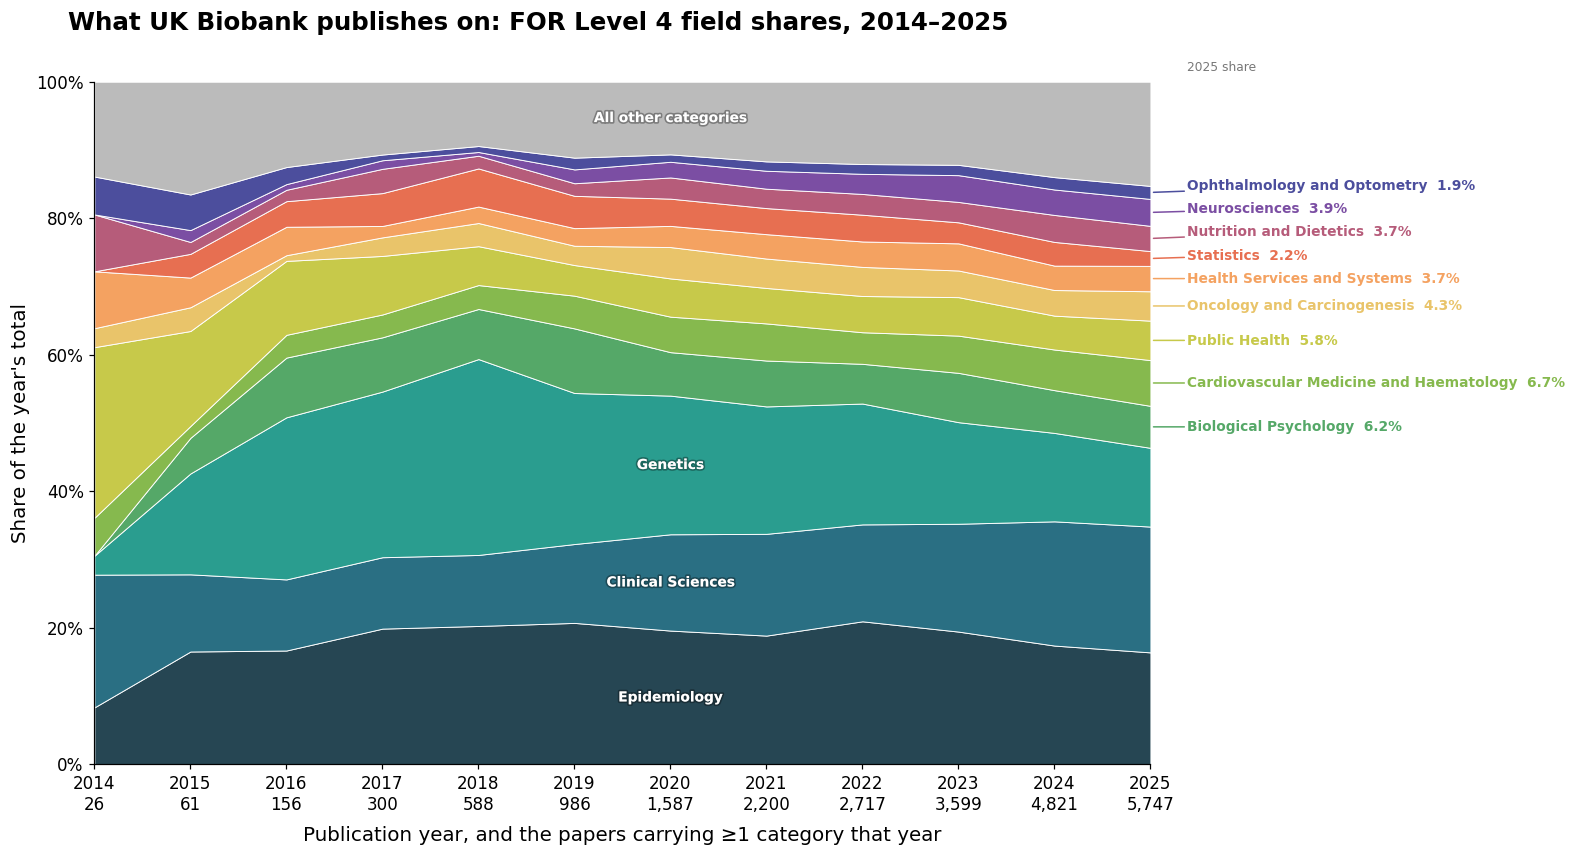

saved output/figures/data_analysis/02_content/06b_for_l4_rank_flow.pdf
saved output/figures/data_analysis/02_content/06b_for_l4_rank_flow.svg


saved output/figures/data_analysis/02_content/06b_for_l4_rank_flow.png


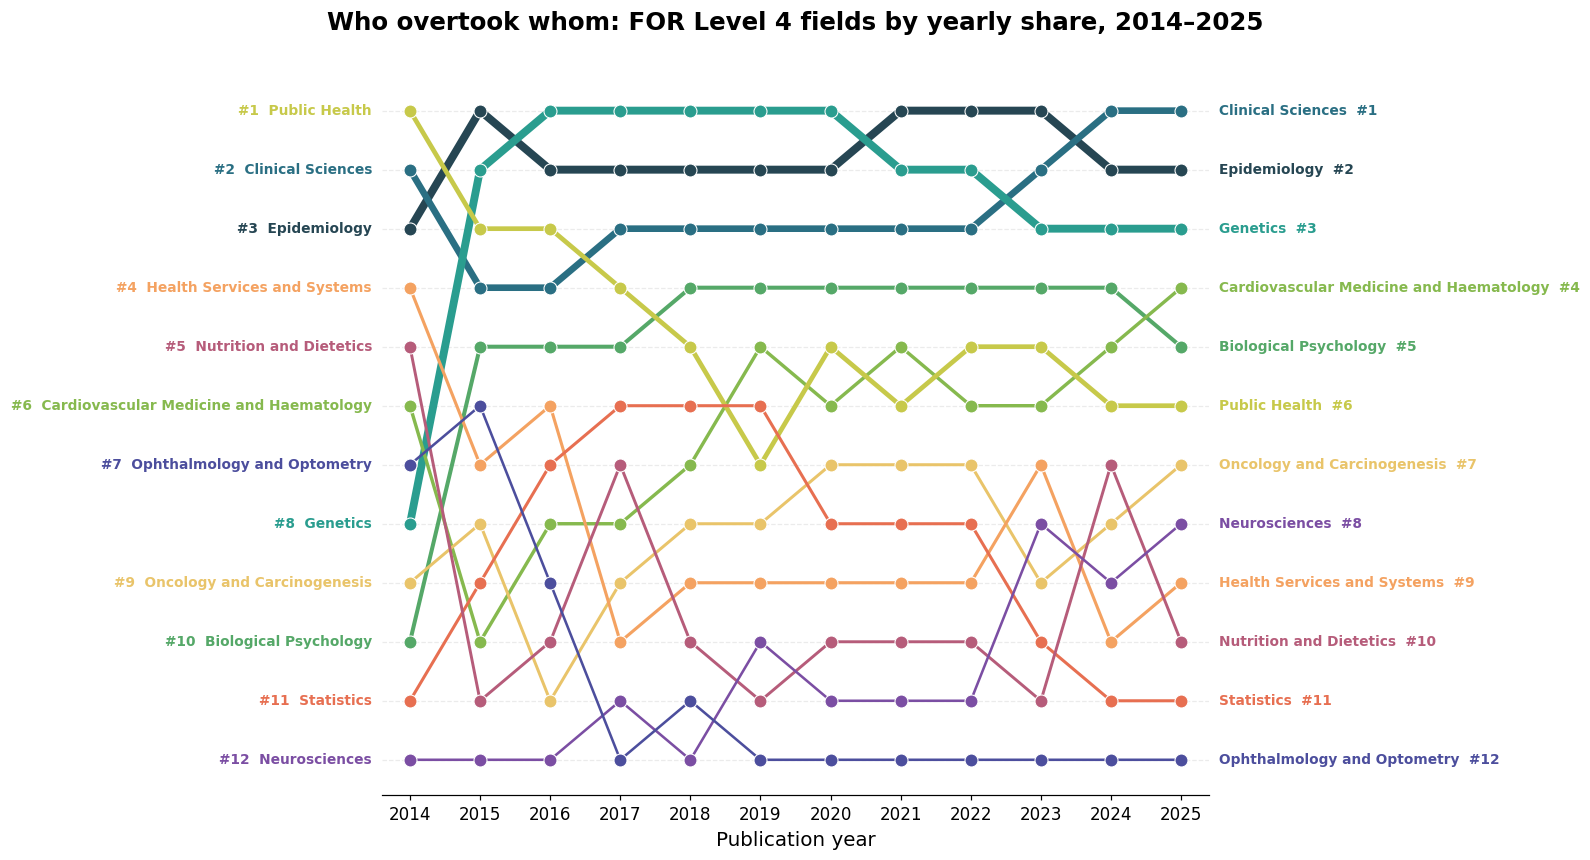

In [19]:
plot_share_stream(
    for_band, for_n,
    f"What UK Biobank publishes on: FOR Level 4 field shares, {FLOW_MIN}–{FLOW_MAX}",
    "",
    "06a_for_l4_share_stream")

plot_rank_flow(
    for_share, for_keep,
    f"Who overtook whom: FOR Level 4 fields by yearly share, {FLOW_MIN}–{FLOW_MAX}",
    "",
    "06b_for_l4_rank_flow")

In [20]:
for_delta = start_end_table(for_share, for_keep, FLOW_YEARS)
display(for_delta)

REG.save_table(for_share.round(4).reset_index(), "for_l4_year_share.csv")
REG.save_table(for_band.round(4).reset_index(), "for_l4_flow_top_bands.csv")
REG.save_table(for_delta.reset_index(), "for_l4_flow_start_vs_end.csv")

P.CONTENT.mkdir(parents=True, exist_ok=True)
for_share.round(6).to_csv(P.CONTENT / "for_l4_year_share.csv")
print("saved", P.raw_path(P.CONTENT / "for_l4_year_share.csv"))

,share_2014_%,share_2025_%,rank_2014,rank_2025,delta_pp,rank_change
category,,,,,,
Genetics,2.78,11.54,11,3,8.76,8
Epidemiology,8.33,16.39,3,2,8.06,1
Biological Psychology,0.00,6.15,33,5,6.15,28
Neurosciences,0.00,3.95,92,8,3.95,84
Statistics,0.00,2.17,112,12,2.17,100
Oncology and Carcinogenesis,2.78,4.31,13,7,1.53,6
Cardiovascular Medicine and Haematology,5.56,6.70,7,4,1.14,3
Clinical Sciences,19.44,18.43,2,1,-1.01,1
Ophthalmology and Optometry,5.56,1.91,8,13,-3.65,-5


saved output/tables/02_content/for_l4_year_share.csv
saved output/tables/02_content/for_l4_flow_top_bands.csv
saved output/tables/02_content/for_l4_flow_start_vs_end.csv
saved data/analysis/content/for_l4_year_share.csv


## 7. RCDC flow, 2014–2025 — **new**

The same analysis on the second vocabulary. **RCDC is flat**: ~270 tags, no levels, no
parent codes, nothing to explode — a paper simply carries a set of them.

Two differences from §6, both forced by that flatness:

**Density.** A paper carries **7.4 RCDC tags** on average against **1.5 FOR L4 codes**, so
whole counting would inflate the year total roughly fivefold over the paper count and let a
paper tagged with twenty conditions outvote one tagged with two. `RCDC_WEIGHT` therefore
defaults to `n_frac`. Set it to `"n_papers"` to see the whole-counting view — the shares
still close at 100%, they just answer a different question.

**Mixed vocabulary.** RCDC puts conditions, research areas and populations in one flat list,
and the largest tags are not diseases: Genetics, Prevention, Human Genome, Clinical Research
and Aging lead the corpus. That is a legitimate answer to *what kind of research is this*,
but not to *what is it about*. `RCDC_VIEW` splits the two through `shared_rcdc.is_disease`.

**The filter runs before normalisation**, so with `RCDC_VIEW="disease"` the shares are of
disease-tagged weight, not of all output. The figure says which denominator it used.

In [21]:
if RCDC_VIEW == "all":
    rcdc_view = rcdc_pairs
    view_note = f"all {rcdc_pairs.rcdc.nunique()} tags"
else:
    want = (RCDC_VIEW == "disease")
    rcdc_view = rcdc_pairs[rcdc_pairs["rcdc"].map(R.is_disease) == want]
    view_note = (f"{rcdc_view.rcdc.nunique()} {RCDC_VIEW} tags of "
                 f"{rcdc_pairs.rcdc.nunique()} (shared_rcdc)")

rcdc_w, rcdc_share, rcdc_n = flow_shares(
    rcdc_view, "rcdc", RCDC_WEIGHT, FLOW_YEARS)
rcdc_band, rcdc_keep, rcdc_order = top_bands(rcdc_share, rcdc_w, TOP_N_FLOW)

_rcov = rcdc_band.drop(columns=[OTHER_LABEL], errors="ignore").sum(axis=1)
print(f"RCDC view '{RCDC_VIEW}': {view_note}; the top {TOP_N_FLOW} hold "
      f"{_rcov.min():.1f}%-{_rcov.max():.1f}% of each year (mean {_rcov.mean():.1f}%)")
display(rcdc_share[rcdc_keep].round(2))

RCDC view 'all': all 271 tags; the top 12 hold 45.6%-57.8% of each year (mean 52.3%)


rcdc,Genetics,Prevention,Human Genome,Clinical Research,Aging,Cardiovascular,Neurosciences,Brain Disorders,Nutrition,Women's Health,Heart Disease,Behavioral and Social Science
year,,,,,,,,,,,,
2014,0.98,4.01,0.98,12.21,2.86,2.03,5.06,5.22,6.15,2.19,0.00,3.93
2015,8.57,4.80,5.18,7.61,3.32,0.55,3.21,3.83,4.16,2.65,0.34,3.50
2016,11.20,7.23,8.56,6.21,3.67,2.93,3.51,2.68,2.98,1.94,1.77,4.17
2017,13.47,6.76,9.74,5.43,2.84,3.04,2.06,2.29,3.72,1.68,2.26,2.75
2018,14.09,6.59,11.14,4.12,2.84,3.69,3.31,2.70,2.59,1.86,2.61,2.22
2019,14.05,6.14,10.84,3.98,3.22,3.73,3.09,3.28,1.82,1.89,2.54,2.36
2020,12.19,6.41,9.40,4.20,3.04,3.11,2.99,2.61,2.16,2.04,2.15,1.84
2021,11.50,6.53,8.53,4.01,3.48,3.52,2.96,3.04,2.10,2.11,2.34,2.02
2022,10.85,6.97,7.73,3.91,3.47,3.37,3.25,2.80,2.38,2.26,2.35,1.87


saved output/figures/data_analysis/02_content/07a_rcdc_share_stream.pdf


saved output/figures/data_analysis/02_content/07a_rcdc_share_stream.svg


saved output/figures/data_analysis/02_content/07a_rcdc_share_stream.png


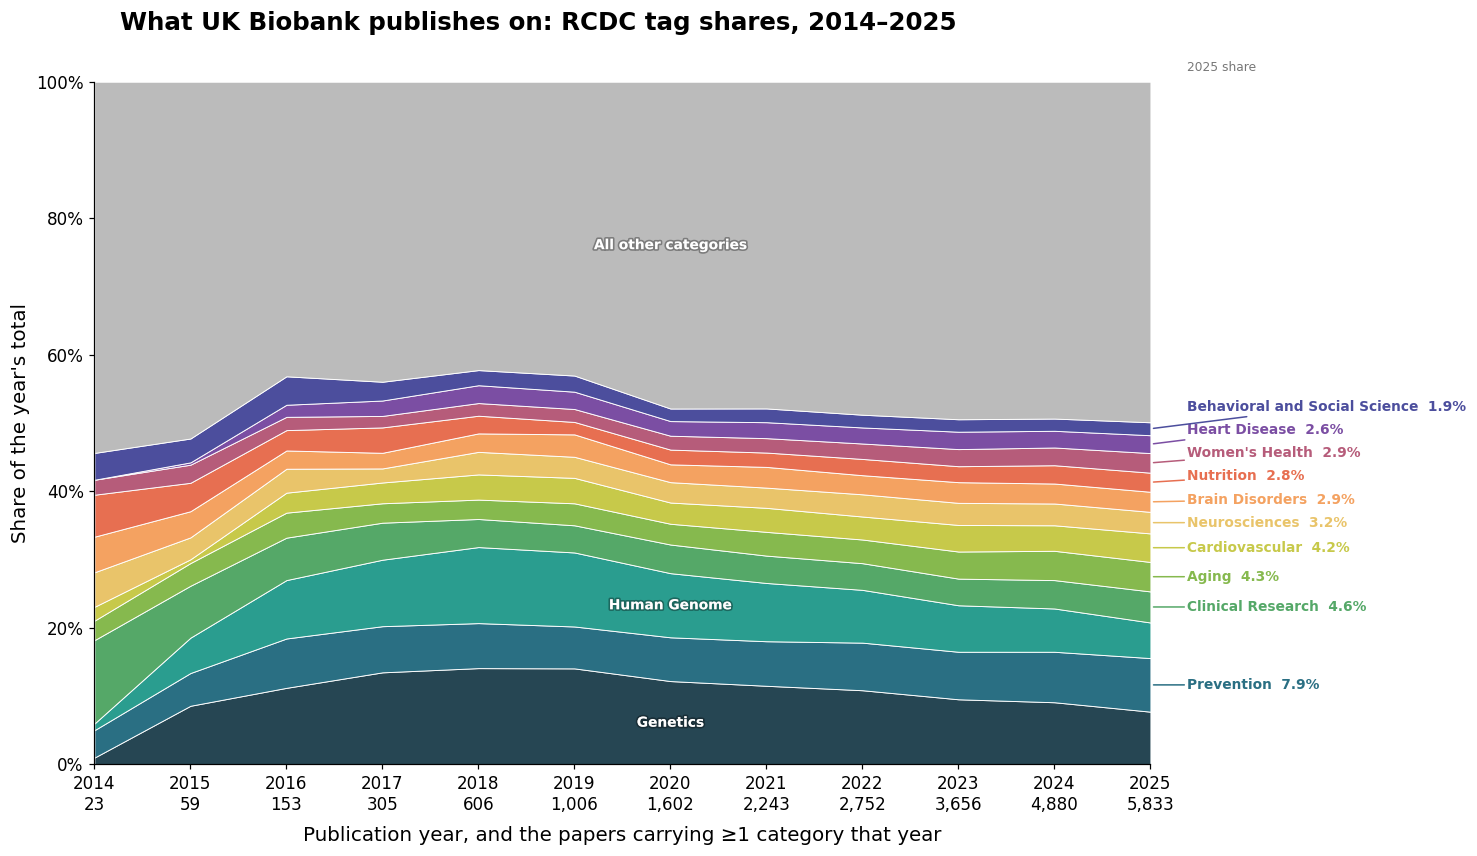

saved output/figures/data_analysis/02_content/07b_rcdc_rank_flow.pdf
saved output/figures/data_analysis/02_content/07b_rcdc_rank_flow.svg


saved output/figures/data_analysis/02_content/07b_rcdc_rank_flow.png


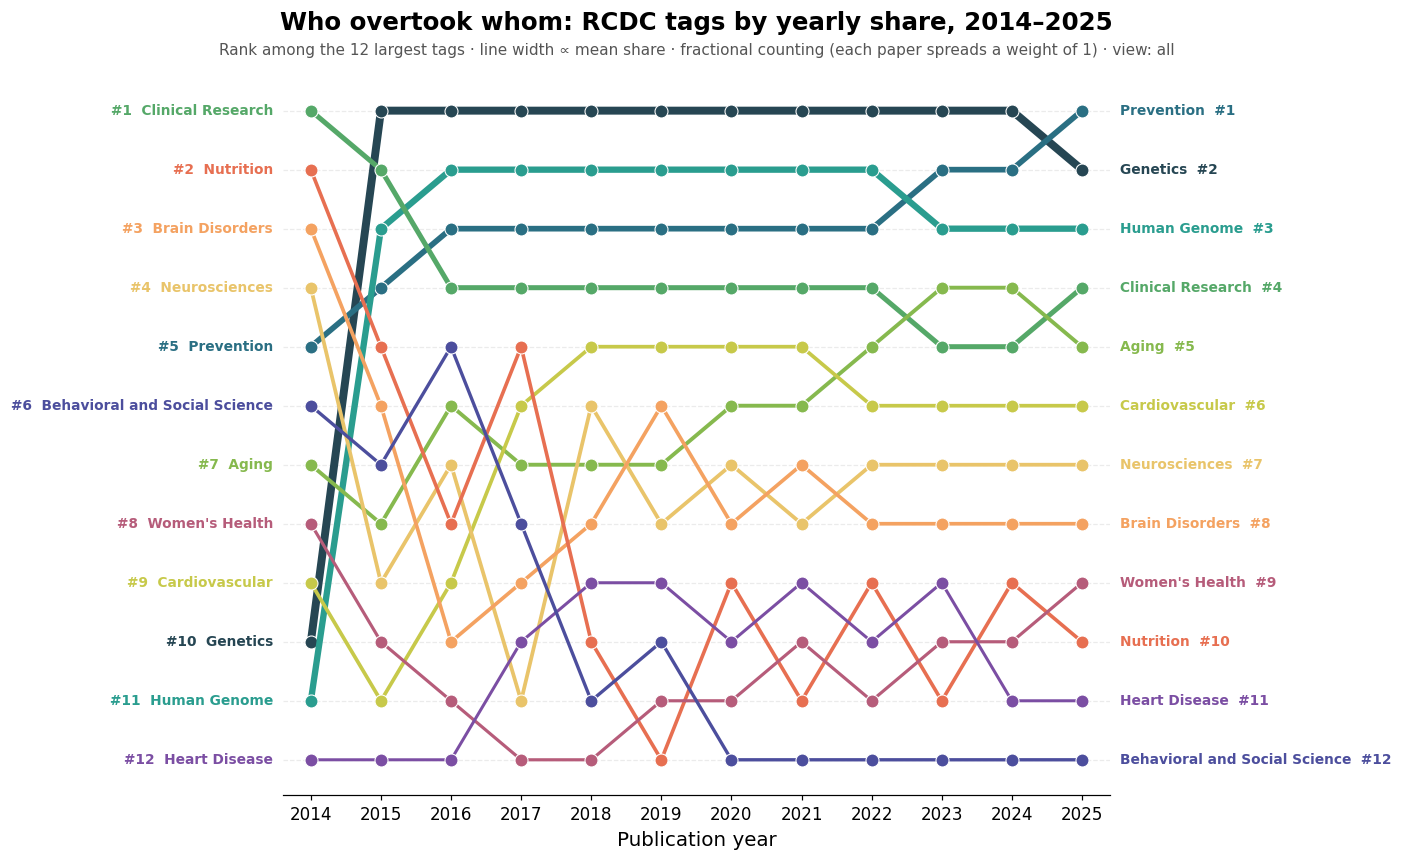

In [22]:
plot_share_stream(
    rcdc_band, rcdc_n,
    f"What UK Biobank publishes on: RCDC tag shares, {FLOW_MIN}–{FLOW_MAX}",
    "",
    "07a_rcdc_share_stream")

plot_rank_flow(
    rcdc_share, rcdc_keep,
    f"Who overtook whom: RCDC tags by yearly share, {FLOW_MIN}–{FLOW_MAX}",
    f"Rank among the {TOP_N_FLOW} largest tags · line width ∝ mean share · "
    f"{_weight_note(RCDC_WEIGHT)} · view: {RCDC_VIEW}",
    "07b_rcdc_rank_flow")

In [23]:
rcdc_delta = start_end_table(rcdc_share, rcdc_keep, FLOW_YEARS)
display(rcdc_delta)

# How much of the 'all' view is cross-cutting rather than disease — the reason the view
# switch exists at all. Fractional, so these two shares add to 100%.
_split = rcdc_pairs.assign(kind=rcdc_pairs["rcdc"].map(R.classify))
_sw, _ss, _ = flow_shares(_split, "kind", RCDC_WEIGHT, FLOW_YEARS)
display(_ss.round(1))

REG.save_table(rcdc_share.round(4).reset_index(), "rcdc_year_share.csv")
REG.save_table(rcdc_band.round(4).reset_index(), "rcdc_flow_top_bands.csv")
REG.save_table(rcdc_delta.reset_index(), "rcdc_flow_start_vs_end.csv")
REG.save_table(_ss.round(4).reset_index(), "rcdc_disease_vs_crosscutting_share.csv")

rcdc_share.round(6).to_csv(P.CONTENT / "rcdc_year_share.csv")
print("saved", P.raw_path(P.CONTENT / "rcdc_year_share.csv"))

,share_2014_%,share_2025_%,rank_2014,rank_2025,delta_pp,rank_change
category,,,,,,
Genetics,0.98,7.71,31,2,6.73,29
Human Genome,0.98,5.21,32,3,4.23,29
Prevention,4.01,7.85,7,1,3.84,6
Heart Disease,0.00,2.62,142,11,2.62,131
Cardiovascular,2.03,4.18,17,6,2.15,11
Aging,2.86,4.32,9,5,1.46,4
Women's Health,2.19,2.87,14,9,0.68,5
Neurosciences,5.06,3.16,4,7,-1.90,-3
Behavioral and Social Science,3.93,1.90,8,13,-2.03,-5


kind,cross-cutting,disease
year,,
2014,54.3,45.7
2015,57.6,42.4
2016,61.4,38.6
2017,62.0,38.0
2018,61.9,38.1
2019,60.4,39.6
2020,59.4,40.6
2021,58.1,41.9
2022,58.5,41.5


saved output/tables/02_content/rcdc_year_share.csv
saved output/tables/02_content/rcdc_flow_top_bands.csv
saved output/tables/02_content/rcdc_flow_start_vs_end.csv
saved output/tables/02_content/rcdc_disease_vs_crosscutting_share.csv
saved data/analysis/content/rcdc_year_share.csv


## 8. Overlap with `03_academic_impact_01_for_analysis.ipynb`

Both notebooks work on FOR 2020 codes, so the question is worth answering explicitly rather
than leaving to a reader's memory.

| this notebook | 03 | overlap? |
|---|---|---|
| §3/§4 per-field summaries: citations, altmetric, h-index, researchers, orgs, % female | nothing of the kind — 03 has no author, org, gender or altmetric measure | **none** |
| §5a most common L4 fields | ranks the top 8 internally to pick chart series, but never draws a volume bar chart | **none in output** |
| §5b / §4 fastest-growing (2024→2025 delta) | Chart 11: CAGR 2021–25 vs 2017–21, world benchmark, acceleration | **yes — 03 supersedes** |
| §6 L4 composition share, summing to 100% within a year | every 03 "share" is UKB ÷ **whole database** *within one field* — a penetration rate, not a composition | **none** |
| §6/§7 stream and bump charts | one two-series `stackplot`, one stacked bar; no stream, alluvial or rank flow | **none** |
| §7 RCDC | 03's RCDC arm is archived at `doc/archive/03_academic_impact_02_rcdc_analysis.ipynb`, out of version control, on the superseded 2014–2024 window | **none live** |

**The two count bases differ.** 03 reads pre-aggregated `(year, code)` partials built from
API-resolved records; this notebook counts off the corpus parquet. The cell below quantifies
the gap rather than leaving it implicit. The corpus side should run slightly **above** 03's,
because the 29 ids the API never resolved are present here — but only slightly, since both
are counting the same publications. A large divergence in any single year would mean one of
the two pathways is wrong, and is worth stopping for.

In [24]:
API_COUNTS = P.FOR_COUNTS_API / "counts.for.ukbb.parquet"
if not API_COUNTS.exists():
    print(f"skipped: {P.raw_path(API_COUNTS)} not on this machine")
else:
    api = pd.read_parquet(API_COUNTS, columns=["year", "level", "code", "for_label",
                                               "n_papers"])
    api = api[(api.level == "L4") & api.year.between(API_MIN, API_MAX)]
    api_year = api.groupby("year").agg(api_pairs=("n_papers", "sum"),
                                       api_fields=("code", "nunique"))

    mine = for_pairs[for_pairs.year.between(API_MIN, API_MAX)]
    my_year = mine.groupby("year").agg(corpus_pairs=("l4_code", "size"),
                                       corpus_fields=("l4_code", "nunique"))
    my_year["corpus_papers"] = mine.drop_duplicates("id").groupby("year").size()

    recon = my_year.join(api_year, how="outer").fillna(0).astype(int)
    recon["pair_diff"] = recon.corpus_pairs - recon.api_pairs
    recon["diff_%"] = (100 * recon.pair_diff / recon.api_pairs.replace(0, np.nan)).round(1)
    display(recon)
    print(f"totals {API_MIN}-{API_MAX}: corpus {recon.corpus_pairs.sum():,} pairs vs "
          f"API {recon.api_pairs.sum():,} — difference "
          f"{recon.pair_diff.sum():,} ({100 * recon.pair_diff.sum() / recon.api_pairs.sum():.1f}%)")

    by_code = (mine.groupby(["l4_code", "l4_label"]).size().rename("corpus_pairs")
               .reset_index()
               .merge(api.groupby(["code", "for_label"])["n_papers"].sum()
                      .rename("api_pairs").reset_index(),
                      left_on="l4_code", right_on="code", how="outer"))
    by_code["diff"] = by_code.corpus_pairs.fillna(0) - by_code.api_pairs.fillna(0)
    REG.save_table(recon.reset_index(), "reconciliation_vs_03_by_year.csv")
    REG.save_table(by_code.sort_values("corpus_pairs", ascending=False),
                   "reconciliation_vs_03_by_field.csv")
    display(by_code.sort_values("corpus_pairs", ascending=False).head(12))

skipped: data/analysis/academic_impact/for_counts_api/counts.for.ukbb.parquet not on this machine


## 9. Coverage and caveats

**Coverage.** 26,109 papers in the corpus. 26,086 (99.9%) carry ≥1 FOR 2020 code, but only
25,402 (97.3%) carry an L4 *field* — the rest carry a 2-digit division only and cannot enter
§6, which spans 119 fields. 25,743 (98.6%) carry ≥1 RCDC tag, 190,511 (paper, tag) pairs
over 271 tags. A paper missing from a flow is missing because it is untagged at that level,
not because it was filtered out.

**Every count in §3–§5 is of paper–category pairs, not papers.** `papers` in those tables
sums to more than the corpus. §6 and §7 make this explicit through the weight parameter
instead: `n_papers` is that same whole counting, `n_frac` is the paper-conserving
alternative.

**The window excludes 2026 deliberately.** 2,667 papers carry a 2026 date and the year is
still accruing; including it would show every category "collapsing". 2013's five papers are
below the left edge. Neither is missing data.

**The left-hand edge is thin.** The corpus holds 27 papers dated 2014 and 63 dated 2015, of
which 26 and 61 carry an L4 field. Read the first two years of every flow figure as
indicative; that population is printed under each year's own x tick.

**The number under each x tick is a population, not a denominator.** It counts papers
carrying ≥1 category that year. The share arithmetic divides by the *weight* total, which
under `n_papers` is the paper–category pair count (larger) and under `n_frac` is the paper
count (identical). Do not read a band's share as a percentage of those papers unless the
weight is fractional.

**A share is not a size.** Every band in §6 and §7 is normalised within its year. The corpus
grew from 27 papers to 5,892 across the window, so a band that narrows is almost never
shrinking in absolute terms — it is growing more slowly than the corpus around it. Read
volume off §5 and §3, never off a band's width.

**§7's denominator depends on `RCDC_VIEW`.** Under `"disease"` or `"cross-cutting"` the
shares are of the filtered subset, not of all output. The stated view travels on the figure.

**Growth in §4 and §5b is superseded** by `03_academic_impact_01_for_analysis.ipynb` Chart
11, for the three reasons set out in §4. It is preserved, not recommended.

**`percent_female` is a floor.** The shared conservative name pipeline is used, but
`unknown` still remains in this legacy metric's denominator.

In [25]:
manifest, _ = REG.save_manifest("02_content_manifest.csv")
display(manifest)

saved output/tables/02_content/02_content_manifest.csv


,kind,name,format,path,size_bytes,sha256
0,figure,05a_for_l4_most_common,pdf,output/figures/data_analysis/02_content/05a_fo...,24039,47ec225cf190889c944dcbecae5ee29db0f512ef0b5477...
2,figure,05a_for_l4_most_common,png,output/figures/data_analysis/02_content/05a_fo...,274834,e2380af9e1cd6ecbeb48e5912f406452ad5339bf35e508...
1,figure,05a_for_l4_most_common,svg,output/figures/data_analysis/02_content/05a_fo...,14715,d73dbb9924bbc4654ddaa291ee154f49fdffb0056c9a29...
3,figure,05b_for_l4_fastest_growing,pdf,output/figures/data_analysis/02_content/05b_fo...,24750,1167ed4e14f29a38c7a99470777dd986f1f4de36c36193...
5,figure,05b_for_l4_fastest_growing,png,output/figures/data_analysis/02_content/05b_fo...,285195,7788a570a33c858eab8b2c0bde13b5ca1c975f9fc19fd4...
4,figure,05b_for_l4_fastest_growing,svg,output/figures/data_analysis/02_content/05b_fo...,14180,ca324425d76aceaf3716bb6846d5ef65d0e154efae5d4a...
6,figure,05c_rcdc_most_common_all,pdf,output/figures/data_analysis/02_content/05c_rc...,23977,50e09ad4afd160f9282ca12a146589195e8e2a814dcef6...
8,figure,05c_rcdc_most_common_all,png,output/figures/data_analysis/02_content/05c_rc...,245137,050d18fb835dc56c2cee3b015f6ccf87769dffd86b3187...
7,figure,05c_rcdc_most_common_all,svg,output/figures/data_analysis/02_content/05c_rc...,14688,a4be4222932fd0f0e839a702fc1c41b1f30a27a995b76d...
9,figure,05d_rcdc_most_common_disease,pdf,output/figures/data_analysis/02_content/05d_rc...,22936,ab1b614c4b3be4692218a1a0d17bc892dd7c3d3c3650d7...
